# Исследование стартапов
- Автор: Васильев Арсений
- Дата: 20.06.2025

## Введение

**Цель проекта** - провести исследовательский анализ данных рынка стартапов, чтобы сформулировать инвестиционные рекомендации на 2015 год.

**Задачи проекта:**
- Выполнить загрузку и предобработку данных (очистка от пропусков, дубликатов, приведение к нужным типам).
- Провести инжиниринг признаков (категоризация стартапов по срокам финансирования и сегментам рынка).
- Найти и обработать аномальные значения (выбросы), чтобы они не искажали результаты.
- Проанализировать динамику инвестиций по годам и выявить наиболее перспективные сегменты и типы финансирования.
- Сформулировать итоговый вывод для инвестора.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Загрузим все данные по проекту. Для данных по возвратам сразу назначим столбец с годом в качестве индекса.

In [2]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", index_col='year')

Выведем первые пять строк и общую информацию о каждом датасете, чтобы оценить структуру, типы данных и пропущенные значения.

In [3]:
display(df.head())
display(df.info())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

None

In [4]:
display(returns.head())
display(returns.info())

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


None

**Вывод о полученных данных:**
- Датасет `cb_returns` имеет размер 15 строк на 13 столбцов. Данные чистые, пропусков нет, типы данных корректные (float64).
- Основной датасет `cb_investments` содержит 54294 строки и 40 столбцов.

**Обнаруженные проблемы:**
- В данных около 4856 абсолютно пустых строк (максимальное число непустых значений в столбцах - 49438, а общий объем - 54294).
- В названиях некоторых столбцов (`' market'`, `' funding_total_usd'`) присутствуют лишние пробелы.
- Столбец `funding_total_usd` имеет тип object (строка) хотя должен быть числовым.
- Все столбцы с датами (`founded_at`, `first_funding_at` и тд) имеют строковый тип object и требуют перевода в формат datetime.
- Присутствуют пропуски в категориальных и текстовых столбцах.

### 1.2. Предобработка данных

Проверим названия столбцов и очистим их от лишних пробелов по краям, чтобы к ним было удобно обращаться.

In [5]:
# удаляем пробелы в начале и конце названий столбцов
df.columns = df.columns.str.strip()

# проверяем
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Уберем выделение разрядов (запятые) в столбце `funding_total_usd` и преобразуем его в числовой формат. Заодно обработаем возможные ошибки конвертации.

In [6]:
# удаляем запятые
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')

# переводим в числа, все остальное меняем на пропуск
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

Переведем столбцы с датами из строкового формата в формат datetime для удобной работы со временем.

In [7]:
columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

C:\Users\Admin\AppData\Local\Temp/ipykernel_4644/639329787.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Обработаем текстовые данные. Заполним пропуски в столбцах с категориями, рынками, статусами и гео-данными заглушкой 'unknown', чтобы не терять строки при анализе.

In [8]:
columns = ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city', 'founded_month', 'founded_quarter']

# добавил очистку пробелов в самих текстовых значениях
for col in columns:
    df[col] = df[col].str.strip()
    
df[columns] = df[columns].fillna('unknown')

Удалим строки в которых нет данных о финансировании (пропуски в `funding_total_usd`), а затем избавимся от полных дубликатов. Также зафиксируем изначальный размер датасета для финальной проверки.

In [9]:
# запомним исходный размер
start_shape = df.shape[0]

# удаляем строки без данных и полные дубликаты
df = df.dropna(subset=['funding_total_usd'])
df = df.drop_duplicates()

Заполним оставшиеся пропуски в столбце `mid_funding_at`. В качестве значения возьмем середину интервала между датами первого `first_funding_at` и последнего `last_funding_at` раундов финансирования.

In [10]:
# находим строки с пропусками
miss_mid = df['mid_funding_at'].isna()

# считаем середину интервала
df.loc[miss_mid, 'mid_funding_at'] = df.loc[miss_mid, 'first_funding_at'] + (df.loc[miss_mid, 'last_funding_at'] - df.loc[miss_mid, 'first_funding_at']) / 2

# считаем оставшиеся пропуски
print("Осталось пропусков в mid_funding_at:", df['mid_funding_at'].isna().sum())

Осталось пропусков в mid_funding_at: 1


Оценим долю отброшенных данных, чтобы убедиться, что мы не удалили слишком много полезной информации.

In [11]:
# Считаем процент потерь
final_shape = df.shape[0]
drop = ((start_shape - final_shape) / start_shape) * 100

print(f"Изначально строк: {start_shape}")
print(f"Осталось строк: {final_shape}")
print(f"Отброшено данных: {drop:.2f}%")

Изначально строк: 54294
Осталось строк: 40907
Отброшено данных: 24.66%


**1. Общая информация о данных**
- Исходный размер данных: основной датасет `cb_investments` изначально содержал 54294 строки и 40 столбцов. Дополнительный датасет `cb_returns` содержал 15 строк (индекс по годам) и 13 столбцов.
- Размер после преобразований: в результате очистки основного датасета от пропусков и дубликатов финальный размер составил 40907 строк. Было отброшено 24.66% данных.
- Описание набора данных: датасеты содержат подробную информацию о стартапах, сегментах рынка, датах раундов финансирования, суммах привлеченных инвестиций и исторических возвратах средств.

**2. Типы данных**
- Выполненные преобразования: столбец с общей суммой инвестиций `funding_total_usd` был очищен от запятых, после чего переведен в числовой формат float. Столбцы с датами (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) были переведены из строкового формата в datetime.
- Корректность: на текущем этапе все ключевые столбцы имеют логичные и оптимизированные типы данных, подходящие для проведения вычислений и анализа.

**3. Пропущенные значения**
- Обнаруженные пропуски: пропущенные значения присутствовали в текстовых столбцах (категории, рынок, статус, география), в датах и в важном столбце `funding_total_usd`.
- Методы обработки: текстовые и категориальные пропуски заполнены строковой заглушкой `unknown`. Пропуски в `mid_funding_at` были математически рассчитаны как середина временного интервала между первым и последним раундами финансирования (остался 1 пропуск из-за нехватки дат). Строки с пропусками в `funding_total_usd` были удалены, тк восстановить суммы инвестиций невозможно, а без них данные не несут ценности.

**4. Дубликаты**
- Явные дубликаты: проведён поиск полностью идентичных строк-дубликатов.
- Метод обработки: все найденные полные дубликаты были удалены из набора данных.

**5. Обработка названий столбцов**
- Названия всех столбцов были проверены и очищены от лишних пробелов в начале и в конце. Теперь все названия столбцов в едином стиле.

**6. Итоговое состояние данных**
- Итоговое количество строк: 40907
- Готовность к анализу: данные очищены от пустых строк без финансовой информации, даты и суммы приведены к правильным типам, названия столбцов приведины к единому формату. Датасет полностью готов к созданию новых признаков и проведению исследовательского анализа.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Рассчитаем продолжительность финансирования в днях. На основе этого разделим компании на три группы: "Единичное финансирование", "Срок финансирования до года" и "Срок финансирования более года".

In [12]:
# считаем разницу в днях
df['funding_duration'] = (df['last_funding_at'] - df['first_funding_at']).dt.days

# функция для определения группы
def group(days):
    if days == 0:
        return 'Единичное финансирование'
    elif days <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

# применяем функцию
df['funding_group'] = df['funding_duration'].apply(group)

Подготовим данные для визуализации, посчитаем количество компаний и сумму инвестиций для каждой группы. Построим две столбчатые диаграммы в единой цветовой гамме для наглядного сравнения.

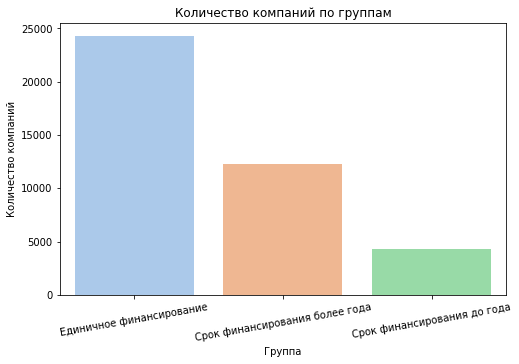

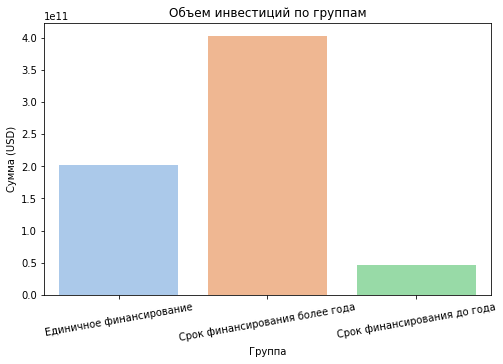

In [13]:
# считаем колво компаний по группам
group_count = df['funding_group'].value_counts().reset_index()
group_count.columns = ['funding_group', 'count']

# считаем сумму инвестиций по группам
group_funding = df.groupby('funding_group')['funding_total_usd'].sum().reset_index()
group_funding.columns = ['funding_group', 'sum']

# график 1 - количество компаний
plt.figure(figsize=(8, 5))
sns.barplot(data=group_count, x='funding_group', y='count', hue='funding_group', palette='pastel')
plt.title('Количество компаний по группам')
plt.xlabel('Группа')
plt.ylabel('Количество компаний')
plt.xticks(rotation=10)
plt.show()

# график 2 - сумма инвестиций
plt.figure(figsize=(8, 5))
sns.barplot(data=group_funding, x='funding_group', y='sum', hue='funding_group', palette='pastel')
plt.title('Объем инвестиций по группам')
plt.xlabel('Группа')
plt.ylabel('Сумма (USD)')
plt.xticks(rotation=10)
plt.show()

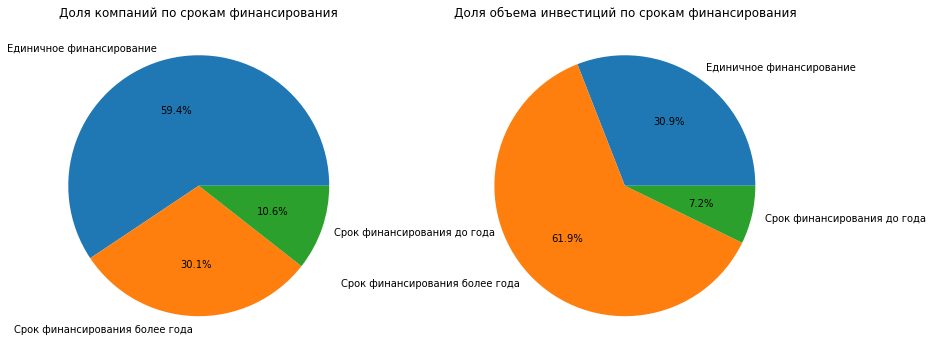

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# график 1 - круговая диаграмма по количеству компаний
axes[0].pie(group_count['count'], labels=group_count['funding_group'], autopct='%1.1f%%')
axes[0].set_title('Доля компаний по срокам финансирования')

# график 2 - круговая диаграмма по объему инвестиций
axes[1].pie(group_funding['sum'], labels=group_funding['funding_group'], autopct='%1.1f%%')
axes[1].set_title('Доля объема инвестиций по срокам финансирования')

plt.show()

Разница между графиками достаточно сильная. Почти 60% компаний привлекают финансирование лишь один раз, большинство из них почти сразу закрываются. Однако 30% проектов, которые смогли показать себя, продолжают привлекать раунды более года и забирают большую долю (более 60%) всего капитала рынка. Инвесторы отдают основные деньги в проверенные компании.

### 2.2 Выделение средних и нишевых сегментов рынка

Подсчитаем, сколько компаний находится в каждом сегменте. Затем с помощью условий разобьем сегменты на три группы:
- массовые (более 120 компаний)
- средние (от 35 до 120)
- нишевые (до 35)

Также построим гистограмму их распределения.

Количество массовых сегментов: 49
Количество средних сегментов: 57
Количество нишевых сегментов: 289


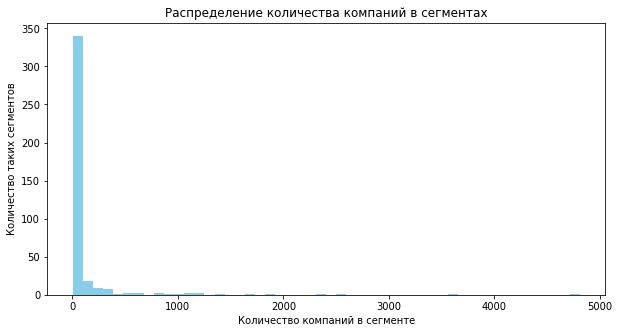

In [15]:
# считаем сколько раз встречается каждый сегмент
market_counts = df['market'].value_counts()

# отбираем сегменты по условиям
high_markets = market_counts[market_counts > 120]
mid_markets = market_counts[(market_counts >= 35) & (market_counts <= 120)]
low_markets = market_counts[market_counts < 35]

print(f"Количество массовых сегментов: {len(high_markets)}")
print(f"Количество средних сегментов: {len(mid_markets)}")
print(f"Количество нишевых сегментов: {len(low_markets)}")

# строим гистограмму
plt.figure(figsize=(10, 5))

plt.hist(market_counts, bins=50, color='skyblue')

plt.title('Распределение количества компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество таких сегментов')

plt.show()

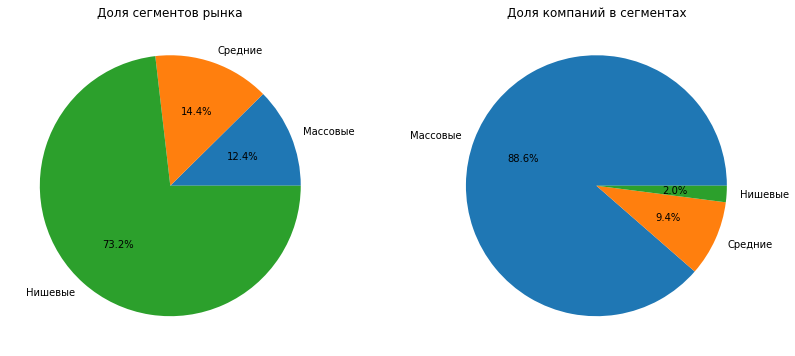

In [16]:
# считаем колво сегментов в каждой группе
segments = pd.Series({
    'Массовые': len(high_markets),
    'Средние': len(mid_markets),
    'Нишевые': len(low_markets)
})

# считаем колво компаний
companies = pd.Series({
    'Массовые': market_counts[high_markets.index].sum(),
    'Средние': market_counts[mid_markets.index].sum(),
    'Нишевые': market_counts[low_markets.index].sum()
})

# строим два круговых графика
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(segments, labels=segments.index, autopct='%1.1f%%')
axes[0].set_title('Доля сегментов рынка')

axes[1].pie(companies, labels=companies.index, autopct='%1.1f%%')
axes[1].set_title('Доля компаний в сегментах')
plt.show()

**Портрет рынка стартапов:** большинство существующих сегментов рынка (73.2%) являются нишевыми (до 35 компаний в каждом). При этом распределение самих компаний противиположно, 88.6% всех стартапов приходятся на небольшое число массовых сегментов.

**Значение такого распределения:** такая структура необходима для развития рынка. Большое количество нишевых сегментов позволяет рынку тестировать много разных нестандартных гипотез. Когда какая-то ниша доказывает свою эффективность, она притягивает внимание к себе, переходит в разряд массовых, и именно туда идет основая масса новых стартапов.

Оставим в данных оригинальные названия только для массовых сегментов. Остальные объединим под общими названиями `mid` и `niche`.

In [17]:
# функция замены сегмента
def replace_market(market):
    if market in high_markets:
        return market
    elif market in mid_markets:
        return 'mid'
    else:
        return 'niche'

# заменяем
df['market'] = df['market'].apply(replace_market)

**1. Анализ групп по срокам финансирования**
- Распределение компаний: большинство стартапов относятся к группе «Единичное финансирование». Проектов, которые привлекали раунды более одного года почти в 2 раза меньше. Еще меньше проектов с финансированием до года (около 5000).
- Распределение инвестиций: почти все инвестиционные средства (около 4e11 USD) забирают проекты из категории «Срок финансирования более года». Единичные раунды и проекты с финансированием до года собирают значительно меньше денег.
- Вывод: большинство стартапов завершают свой путь после первого раунда. Инвесторы предпочитают отдавать основной капитал в проверенные проекты, которые стабильно развиваются.

**2. Анализ сегментов рынка**
- Структура рынка: на 49 массовых сегментов приходится огромное количество компаний, 289 сегментов являются нишевыми (до 35 компаний).
- Оптимизация данных: на гистограмме виден длинный хвост из множества мелких направлений. Замена индивидуальных названий у средних и нишевых сегментов на заглушки `mid` и `niche` упростит дальнейший анализ.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

Графически оценим типичный размер общего финансирования для одной компании. Построим диаграмму размаха. Также выведем числовое описание с помощью метода describe().

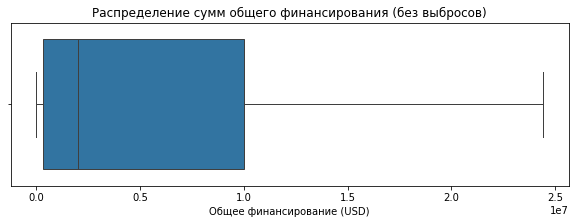

Граница верхнего уса (типичные значения): 24475000.0
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


In [18]:
# строим график
plt.figure(figsize=(10, 3))

sns.boxplot(x=df['funding_total_usd'], showfliers=False)

plt.title('Распределение сумм общего финансирования (без выбросов)')
plt.xlabel('Общее финансирование (USD)')

plt.show()

# считаем границу типичных значений
q1 = df['funding_total_usd'].quantile(0.25)
q3 = df['funding_total_usd'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Граница верхнего уса (типичные значения): {upper}")

# выводим числовую статистику
print(df['funding_total_usd'].describe())

Определим аномальные инвестиции с помощью метода межквартильного размаха (IQR). Для каждого сегмента рынка (массовые, mid, niche) посчитаем свои границы. Значения, которые превышают верхнюю границу (Q3 + 1.5 * IQR), пометим как выбросы в новом столбце `is_outlier`.

In [19]:
# создаем столбец
df['is_outlier'] = False

# цикл по уникальным сегментам
for market_name in df['market'].unique():
    # отбираем суммы только для текущего сегмента
    market_data = df[df['market'] == market_name]['funding_total_usd']
    
    # считаем IQR
    q1 = market_data.quantile(0.25)
    q3 = market_data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    
    # находим строки с аномальной суммой и ставим true
    df.loc[(df['market'] == market_name) & (df['funding_total_usd'] > upper_bound), 'is_outlier'] = True

print(f"Количество аномальных компаний: {df['is_outlier'].sum()}")

Количество аномальных компаний: 5244


Найдем сегменты с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ 10 таких сегментов.

In [20]:
# считаем долю выбросов по сегментам
outlier_percent = df.groupby('market')['is_outlier'].mean() * 100

print(outlier_percent.sort_values(ascending=False).head(10))

market
Real Estate        17.204301
Entertainment      16.666667
Consulting         16.618911
Search             16.494845
Cloud Computing    16.447368
Photography        16.176471
SaaS               16.176471
Technology         15.966387
Video              15.957447
niche              15.903614
Name: is_outlier, dtype: float64


### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим, полные ли данные за 2014 год. Для этого посмотрим, сколько раундов финансирования фиксировалось каждый месяц в 2014 году. Затем очистим данные, удалим строки с выбросами.

In [21]:
# выделяем год и месяц
df['last_funding_year'] = df['last_funding_at'].dt.year
df['last_funding_month'] = df['last_funding_at'].dt.month

# смотрим распределение по месяцам в 14 году
print(df[df['last_funding_year'] == 2014]['last_funding_month'].value_counts().sort_index())

# исключаем аномалии
df_clean = df[df['is_outlier'] == False].copy()
print(f"Осталось строк после удаления выбросов: {df_clean.shape[0]}")

last_funding_month
1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1135
10    1139
11     732
12      52
Name: count, dtype: int64
Осталось строк после удаления выбросов: 35663


На основе столбцов `mid_funding_at` и `funding_rounds` оставим данные только о компаниях, получавших деньги в те годы, когда суммарно по датасету было зафиксировано 50 или более раундов финансирования.

In [22]:
# выделяем год
df_clean['mid_funding_year'] = df_clean['mid_funding_at'].dt.year

# считаем колво раундов в каждому году
rounds_per_year = df_clean.groupby('mid_funding_year')['funding_rounds'].sum()

# отбираем года
active_years = rounds_per_year[rounds_per_year >= 50].index

# оставляем компании из активных лет
df_filtered = df_clean[df_clean['mid_funding_year'].isin(active_years)].copy()

print(f"Года, оставшиеся в анализе: {list(active_years)}")
print(f"Строк после фильтрации годов: {df_filtered.shape[0]}")

Года, оставшиеся в анализе: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Строк после фильтрации годов: 35588


### 3.3. Анализ типов финансирования по объёму и популярности

Построим столбчатую диаграмму, чтобы увидеть какие типы финансирования привлекли больше всего денег.

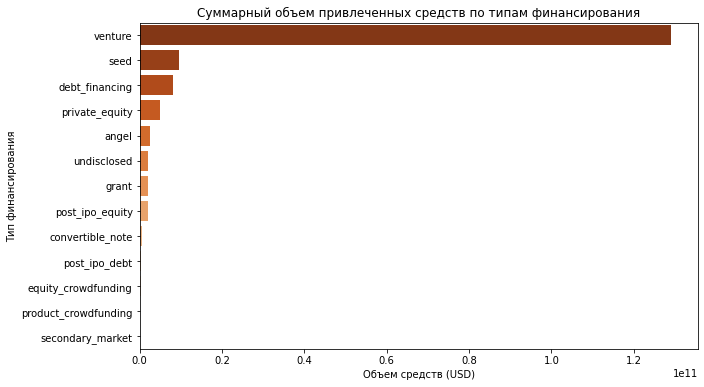

In [23]:
# столбцы с типами
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# считаем суммы
total_by_type = df_filtered[funding_types].sum().sort_values(ascending=False).reset_index()

# переименовываем колонки для удобства
total_by_type.columns = ['funding_type', 'total_usd']

# строим график
plt.figure(figsize=(10, 6))

sns.barplot(data=total_by_type, x='total_usd', y='funding_type', hue='funding_type', palette='Oranges_r')

plt.title('Суммарный объем привлеченных средств по типам финансирования')
plt.xlabel('Объем средств (USD)')
plt.ylabel('Тип финансирования')

plt.show()

Теперь посмотрим на популярность, как часто компании используют каждый из типов. Посчитаем количество случаев, когда сумма по типу больше нуля.

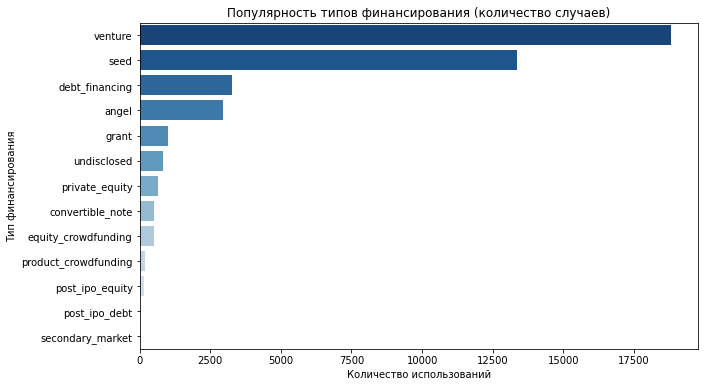

In [24]:
# считаем колво случаев
pop_by_type = (df_filtered[funding_types] > 0).sum().sort_values(ascending=False).reset_index()
pop_by_type.columns = ['funding_type', 'count']

# строим график
plt.figure(figsize=(10, 6))

sns.barplot(data=pop_by_type, x='count', y='funding_type', hue='funding_type', palette='Blues_r')

plt.title('Популярность типов финансирования (количество случаев)')
plt.xlabel('Количество использований')
plt.ylabel('Тип финансирования')

plt.show()

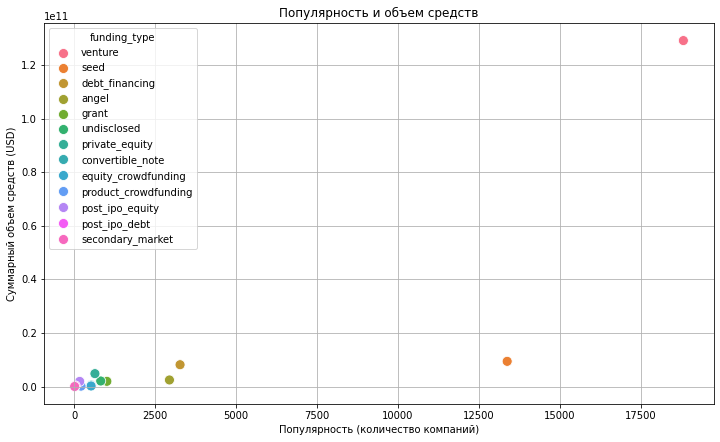

In [25]:
# объединяем популярность и объем
compare_df = pd.merge(pop_by_type, total_by_type, on='funding_type')

# строим точечный график
plt.figure(figsize=(12, 7))

sns.scatterplot(data=compare_df, x='count', y='total_usd', hue='funding_type', s=100, color='blue')

plt.title('Популярность и объем средств')
plt.xlabel('Популярность (количество компаний)')
plt.ylabel('Суммарный объем средств (USD)')
plt.grid()

plt.show()

**Анализ популярности и объемов привлеченных средств:** в правом верхнем углу расположен абсолютный лидер - venture (и сверхпопулярно, и огромные объемы). В левом нижнем углу скопились большинство типов финансирования. Некоторые из них, например debt financing и angel имеют чуть большую популярность. Правее, в нижнем секторе расположился seed, что говорит о большой популярности.

На основе дополнительного датасета `cb_returns` построим график суммарных возвратов от разных типов финансирования за весь доступный период.

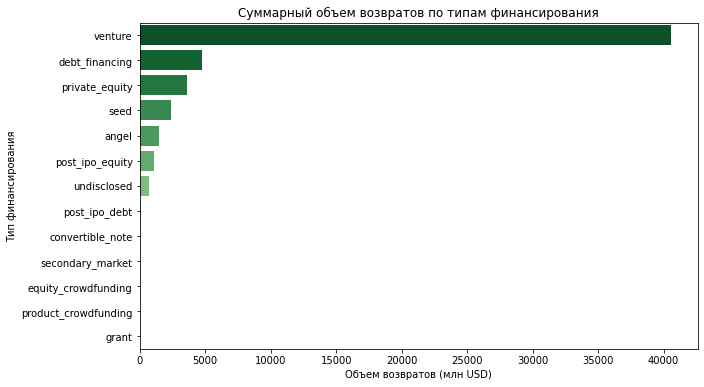

In [26]:
# суммируем возвраты
total_returns = returns.sum().sort_values(ascending=False).reset_index()
total_returns.columns = ['funding_type', 'return_amount']

# строим график
plt.figure(figsize=(10, 6))

sns.barplot(data=total_returns, x='return_amount', y='funding_type', hue='funding_type', palette='Greens_r')

plt.title('Суммарный объем возвратов по типам финансирования')
plt.xlabel('Объем возвратов (млн USD)')
plt.ylabel('Тип финансирования')

plt.show()

**1. Анализ типичных инвестиций и аномалий**
- *Типичные суммы: расчет показал, что верхняя граница нормального объема привлеченных средств (верхний ус) составляет 24.47 млн долларов. При этом половина всех компаний (медиана) привлекает до 2 млн долларов, а 75% укладываются в 10 млн. Всё, что превышает границу уса в 24.5 млн (и доходит до максимума в 30 млрд) - это уже единичные, аномально крупные инвестиции (выбросы), которые мы исключим из дальнейшего анализа.*
- Выбросы: с помощью метода межквартильного размаха (IQR) было найдено 5202 компании с аномально высоким объемом финансирования. Больше всего таких проектов наблюдается в сегментах недвижимости (Real Estate), технологий (Technology) и поиска (Search) - там доля аномальных инвестиций превышает 16%.

**2. Определение границ периода и фильтрация**
- Полнота данных за 2014 год: анализ активности по месяцам показал, что предоставленные данные за 2014 год неполные. Если с января по октябрь стабильно фиксировалось более 1000 раундов, то в ноябре наблюдается просадка, а за декабрь внесено всего 52 записи.
- Очистка данных: из датасета были исключены все строки с аномальным финансированием. Также данные были отфильтрованы по годам с нужной инвестиционной активностью (от 50 раундов в год). В результате сформирован финальный чистый набор данных из 35629 строк, охватывающий период с 2000 по 2014 год.

**3. Анализ типов финансирования (объем, популярность и возвраты)**
- Лидер: венчурное финансирование (venture) является фаворитом рынка. Оно лидирует с большим отрывом по всем параметрам: чаще всего используется компаниями, собирает самую большую долю от общего объема вложенных денег и создает большую часть возвратов.
- Популярные, но дешевые: seed и angel используются стартапами очень активно (seed занимают второе место по частоте использования). Но размеры чеков там не большие, поэтому суммарные объемы привлеченных средств и возвратов по ним не так высоки.
- Редкие, но крупные: стартапы прибегают к debt financing и private equity намного реже, но при этом они занимают лидирующие позиции по суммарным объемам вложений и расположены за венчуром по суммам возвратов.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Рассчитаем средний объем одного раунда для каждой компании, используя столбцы `funding_total_usd` и `funding_rounds`. Затем сгруппируем данные по годам (используем `mid_funding_year`, по которому ранее отбирали активные годы),найдем медианный размер раунда и суммарное количество раундов за каждый год. На основе этих данных построим 2 графика: динамику типичного размера средств, полученных в рамках одного раунда, и динамику общего количества раундов.

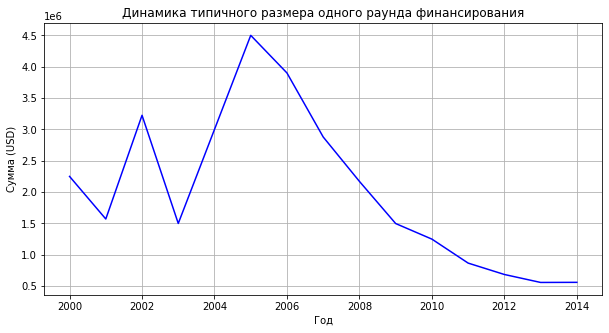

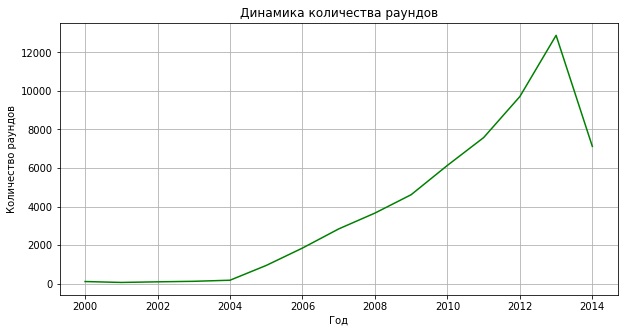

In [27]:
# считаем средний размер раунда для каждой компании
df_filtered['avg_round_usd'] = df_filtered['funding_total_usd'] / df_filtered['funding_rounds']

# группируем по годам, находим медиану и сумму
year_stat = df_filtered.groupby('mid_funding_year').agg(
    round_size=('avg_round_usd', 'median'),
    total_rounds=('funding_rounds', 'sum')
).reset_index()

# график 1 - динамика типичного размера средств в раунде
plt.figure(figsize=(10, 5))
sns.lineplot(data=year_stat, x='mid_funding_year', y='round_size', color='blue')
plt.title('Динамика типичного размера одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Сумма (USD)')
plt.grid()
plt.show()

# график 2 - динамика количества раундов
plt.figure(figsize=(10, 5))
sns.lineplot(data=year_stat, x='mid_funding_year', y='total_rounds', color='green')
plt.title('Динамика количества раундов')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid()
plt.show()

**1. Типичный размер инвестиций**
- Пик медианного размера средств, привлекаемых стартапом в рамках одного раунда, пришелся на 2005 год и составил 4.5 млн usd. После начался многолетний тренд на снижение. Это говорит о том, что со временем рынок стал доступнее, инвесторы начали вкладывать меньше, но в большее количество проектов (это можно увидеть на втором графике).

**2. Тенденции 2014 года**
- Количество раундов: на графике активности наблюдается резкий обвал - число раундов упало с 12907 (2013 год) до 7146. Скорее всего, это произошло из-за того, что данные за ноябрь и декабрь 2014 года практически отсутствуют. Именно это дало сильную просадку на графике.
- Размер выделяемых средств: несмотря на сокращение количества зафиксированных сделок, размер типичного раунда в 2014 году прекратил падение. Также он показал небольшой рост по сравнению с 2013 годом.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу суммарного финансирования по годам. Отфильтруем ее, оставим только массовые сегменты (исключив заглушки mid и niche) и отберем те, которые показали рост в 2014 году по сравнению с 2013. Построим соответствующий график.

Массовые сегменты с ростом в 2014 году:
['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical', 'Real Estate', 'SaaS', 'Startups', 'Technology', 'unknown']


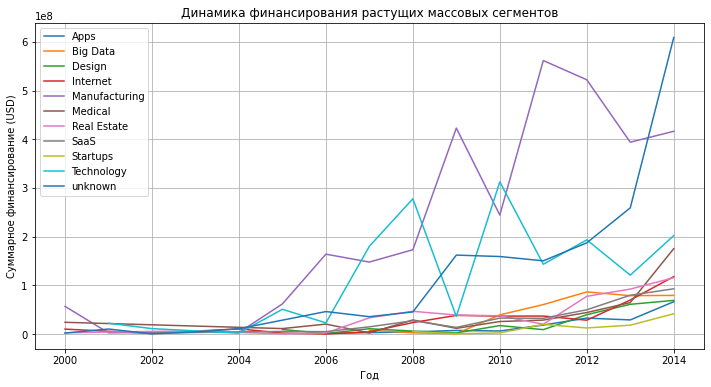

In [28]:
# оставляем только массовые сегменты
mass_df = df_filtered[~df_filtered['market'].isin(['mid', 'niche'])]

# строим сводную таблицу
pivot_funding = mass_df.pivot_table(index='mid_funding_year', columns='market', values='funding_total_usd', aggfunc='sum')

# ищем сегменты где сумма в 14 году больше чем в 13
grow_segments = pivot_funding.columns[pivot_funding.loc[2014] > pivot_funding.loc[2013]]

print(f"Массовые сегменты с ростом в 2014 году:\n{list(grow_segments)}")

# строим линейный график
plt.figure(figsize=(12, 6))

# цикл по каждому растущему сегменту
for segment in grow_segments:
    sns.lineplot(x=pivot_funding.index, y=pivot_funding[segment], label=segment)

plt.title('Динамика финансирования растущих массовых сегментов')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (USD)')
plt.legend()
plt.grid()

plt.show()

**1. Категория unknown**
- Лидером по общему объему привлеченных средств в 2014 году и по скорости роста стала категория unknown (компании без указанного сегмента рынка). Большая доля нового капитала уходит в инновационные проекты, которые не попадают в старые категории, либо стартапы перестали детально заполнять профили при привлечении крупных раундов.

**2. Медицина и технологии**
- Если исключить категорию с пропусками, самыый сильный рост показывают Technology (Технологии), Medical (Медицина) и Internet (Интернет). Также выделяется медицинский сектор, который показал один из самых высоких скачков по сравнению с 2013 годом. Инвесторы вкладываются в сложные технологические и медицинские решения.

**3. Самые быстрорастущие ниши**
- Самый агрессивный рост показали мобильные приложения (Apps) и инфраструктурные проекты для самих стартапов (Startups). В абсолютных деньгах они уступают той же медицине, но скорость притока инвестиций достаточно высока.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Необходимо для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Построим график с нормированными значениями возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

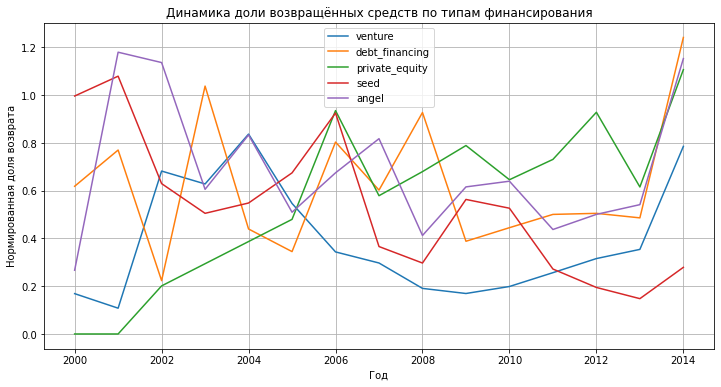

In [29]:
# список нужных типов
types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# считаем сумму по годам (в обычных долларах)
funding_by_year = df_filtered.groupby('mid_funding_year')[types].sum()

# умножим на миллион чтобы привести к долларам
returns_filtered = returns[types] * 1000000

# считаем долю возврата
return_percent = returns_filtered / (funding_by_year + 1e-60)

# заменяем большие выбросы на пустоту
return_percent[return_percent > 20] = None

# строим график
plt.figure(figsize=(12, 6))

# цикл по всем типам
for col in types:
    sns.lineplot(x=return_percent.index, y=return_percent[col], label=col)

plt.title('Динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Нормированная доля возврата')
plt.legend()
plt.grid()

plt.show()

**1. Типы финансирования с наиболее устойчивым ростом**
- Наиболее устойчивый и уверенный рост доли возвращенных средств (начиная примерно с 2009-2010 годов) показывает private equity. К 2014 году этот тип финансирования вышел на первое место по доходности.
- Также уверенный рост после 2009 года показывают венчурные инвестиции (venture). Доля их возврата плавно и стабильно увеличивается до 2014 года.

**2. Волатильные типы финансирования**
- Линия debt financing ведет себя крайне нестабильно, показывает резкие скачки и падения на протяжении всего периода (с пиками в 2003, 2008 и 2014 годах).
- seed и angel демонстрируют падение после 2010 года (с небольшим ростом angel в 2014). seed падает почти постоянно.

**Эффективность**: снижение доли возврата на графике (особенно ближе к 2014 году) не означает, что инвестиции стали менее эффективными. Обычно стартапу нужны годы, чтобы запуститься, вырасти и начать приносить прибыль. Деньги, которые инвесторы вложили в проекты на ранних стадиях в 2013-2014, не успели вернуться к моменту выгрузки этого датасета. Скорее всего на графике видно падение не потому что проекты провальные, а потому что еще не было возврата средств.


## Шаг 5. Итоговый вывод и рекомендации

### Инвестиционная рекомендация на 2015 год

**Приоритетные отрасли для инвестиций:**
1.  Отрасли медицины (Medical) и технологий (Technology). Они показывают уверенный и предсказуемый многолетний рост.
2.  Сегмент недвижимости (Real Estate). В 2013-2014 годах показал сильный рост привлеченного капитала.
3.  Мобильные приложения (Apps). Отрасль показала резкий прирост (более чем в 2 раза за год).

**Оптимальные инвестиции:**
1.  Private Equity. Показал самый устойчивый и быстрый рост доли возвращенных средств за последние пять лет (с 2010 по 2014 год).
2.  Венчурное финансирование (Venture). Это лидер рынка по объему, популярности и суммарным возвратам. 
3. Также рекомендуется избегать инвестиций в seed и angel из-за их падающей доходности.

### Итоги проекта

**1. Выполненные шаги:**
- Предобработка: данные очищены от полных дубликатов и пустых строк (отсутствие финансовой информации). Текстовые пропуски заполнены заглушками, типы данных преобразованы в подходящие для вычислений форматы (даты, числа).
- Инжиниринг признаков: рассчитана продолжительность финансирования, стартапы разбиты на группы. Сегменты рынка классифицированы на массовые, средние и нишевые для удобства анализа.
- Работа с выбросами: с помощью межквартильного размаха (IQR) выявлены и удалены аномально высокие инвестиции. Исключены неактивные годы (менее 50 раундов).
- Анализ динамики: изучены изменения размера раундов финансирования по годам, выявлены самые быстрорастущие сегменты и проанализирована окупаемость.

**2. Ключевые выводы:**
- Венчурный рынок - это долгие инвестиции. Большинство стартапов закрываются после первого раунда, но большая доля капитала достается компаниям, которые способны привлекать средства более года.
- После пика в 2005 году инвесторы стали выделять меньшие суммы в рамках одного раунда, но при этом распределяют их между большим числом проектов.

**3. Согласованность выводов и возможные сомнения:**
- В целом выводы согласуются между собой. Проекты с высокими рисками показывают падение окупаемости. Более безопасные - наращивают доходность. Интерес инвесторов смещается в сторону сложных или масштабных проектов (медицина, недвижимость).
- Сомнения вызывает резкий рост категории unknown в 2014 году. Это говорит либо о появлении новых категорий, либо об ухудшении качества заполнения баз данных. Также резкий обвал количества раундов в конце 2014 года потребовал ручной фильтрации, без этого данные могли привести к неправильным выводам об искусственном падении рынка.